In [7]:
import numpy as np
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm

In [19]:
#fixed parameters
T_LISA = 2 #0.1 #observation time, years. Should be 2.0 for actual runs.
dt = 10.0 #sampling interval, seconds

m1 = 1e6 #MBH mass in solar masses (source frame)
m2 = 10.0 #secondary mass in solar masses (source frame)
x0 = 1.0 #inclination, must be = 1.0 for equatorial model
p0_buffer = 0.02 #0.5 #while p0 will be determined by T_LISA assuming a plunging EMRI, the StableEMRIFisher code may not be suitable for plunge cases. We thus introduce this small buffer to extend the inspiral.

# initial phases
Phi_phi0 = 0.1 #azimuthal phase
Phi_theta0 = 0.2 #polar phase
Phi_r0 = 0.3 #radial phase

# define the extrinsic parameters
qK = np.pi / 5  # polar spin angle
phiK = np.pi / 6  # azimuthal viewing angle
qS = np.pi / 3  # polar sky angle
phiS = np.pi / 4  # azimuthal viewing angle
dist = 1.0  # distance in Gpc. We'll adjust this later to fix the SNR as SNR_fixed.
distval=1.0*58.09 #Single value for Miaoxin
SNR_fixed = 20.0 #desired SNR throughout the grid. 
chi2 = 0.5 #dimensionless secondary spin

filename = f'SK_chi2precision_ae_grid' #filename
if not os.path.exists(filename):
    print("grid data not found")

filename_Fisher = f'Fishers' #subfolder where all the Fisher matrices will be stored.
filename_Fisher = os.path.join(filename,filename_Fisher)


In [20]:
#grid parameters over (a and e0)

N = 10 #no. of points along each axis

try:
    with h5py.File(f"{filename}/data.h5", "r") as f:
        param_grid = f["gridpoints"][:]  # Read the dataset into a NumPy array
        p_range = f["p0"][:] + p0_buffer #buffer
    try:
        with h5py.File(f"{filename}/data.h5", "r") as f:
            dist_range = f["dists"][:]  # Read the dataset into a NumPy array
    except KeyError:
        pass #will be handled later
        
except FileNotFoundError:
    print("grid data not found")

In [21]:
#evaluating and saving the Fisher matrices along the grid
for i in tqdm(range(len(param_grid))):

    try:
        #skip Fisher calculation for ones already calculated
        with h5py.File(f"{filename_Fisher}/Fisher_{i}.h5", "r") as f:
            _ = f["Fisher"][:]
        continue

    except FileNotFoundError:
        print("Fisher not found")

100%|███████████████████████████████████████| 100/100 [00:00<00:00, 1489.45it/s]


In [22]:
#choose parameter ranges here
a_range = np.linspace(0.1,0.9,N)
e_range = np.linspace(0.1,0.5,N) 
    
# Generate the Cartesian product of all parameter values
#param_grid = np.array(list((product(a_range, e_range))))

try:
    with h5py.File(f"{filename}/data.h5", "r") as f:
        param_grid = f["gridpoints"][:]  # Read the dataset into a NumPy array
        p_range = f["p0"][:] + p0_buffer #buffer
    try:
        with h5py.File(f"{filename}/data.h5", "r") as f:
            dist_range = f["dists"][:]  # Read the dataset into a NumPy array
    except KeyError:
        print("values not found")
except FileNotFoundError:
    print("values not found")

In [32]:
#check Positive Semi-Definiteness of the transformed Fisher Matrices, compute the variances on chi2, save corner plots as quick check
from stableemrifisher.plot import CovEllipsePlot

param_names = ['m1','m2','a','chi2','p0','e0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0'] #parameters to be varied at each grid point.

print("Checking log-mass Fisher positive-definiteness...")

check_flag = True
variances=np.zeros(len(param_grid))

for i in tqdm(range(len(param_grid))):

    with h5py.File(f"{filename_Fisher}/Fisher_{i}.h5", "r") as f:
        Fisher = f["Fisher"][:]

    with h5py.File(f"{filename_Fisher}/Fisher_{i}.h5", "r") as f:
        Fisher_transformed = f["Fisher_transformed"][:]
        covariance=np.linalg.inv(Fisher_transformed)
        variances[i]=covariance[3,3] #The diagonal corresponding to chi_2 in the covariance matrix

        a=param_grid[i,0]
        e0=param_grid[i,1]
        p0=p_range[i]
        wave_params = {}
        param_vals = [np.log(m1), np.log(m2), a, chi2, p0, e0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_r0]
        
        for j in range(len(param_names)):
            wave_params[param_names[j]] = param_vals[j]
            
        # fig, axs = CovEllipsePlot(covariance, param_names = param_names, wave_params = wave_params)
        # plt.savefig(rf'cornerplots/conerplot_{i}.pdf')

    #if you want to exclude sus parameters for troubleshooting
    rows_to_remove = []
    for j in range(len(param_names)):
        if param_names[j] in []:#'dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']:
            rows_to_remove.append(j)

    rows_to_remove = np.array(rows_to_remove)
    
    if len(rows_to_remove) > 0:
        Fisher_transformed = np.delete(np.delete(Fisher_transformed,rows_to_remove,axis=0),rows_to_remove,axis=1)
        Fisher = np.delete(np.delete(Fisher,rows_to_remove,axis=0),rows_to_remove,axis=1)

    if (np.linalg.eigvals(Fisher_transformed) < 0.0).any():
        check_flag = False
        raise ValueError('positive definiteness failed for: ', i)
        
if check_flag:
    print("positive-definiteness check passed!")

Checking log-mass Fisher positive-definiteness...


100%|███████████████████████████████████████| 100/100 [00:00<00:00, 1100.84it/s]

positive-definiteness check passed!


/var/folders/zh/xg6wn_ks66j1gflgdjcdrgpr0000gn/T/ipykernel_11899/2515270478.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


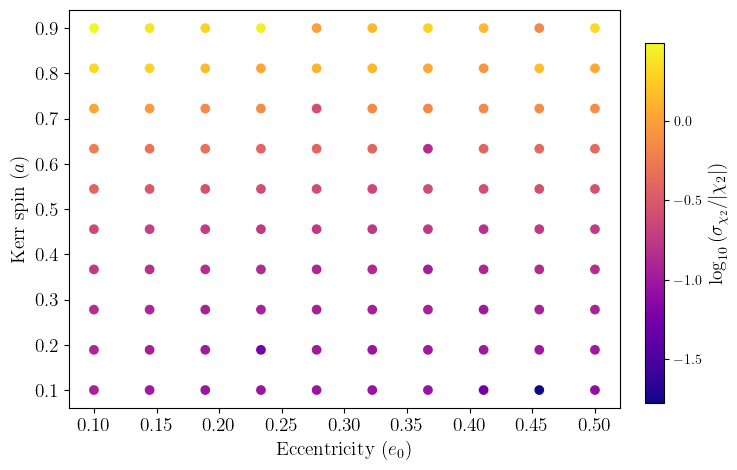

In [38]:
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern"]

label_fontsize = 14
tick_fontsize = 14
title_fontsize = 16

a_vals=param_grid[:, 0]
e_vals=param_grid[:, 1]

fig, axes = plt.subplots() 

# scatter plot
scatter1 = axes.scatter(e_vals,a_vals, c=np.log10(np.sqrt(variances)/abs(chi2)), cmap='plasma',rasterized=True)
axes.set_xlabel(r'Eccentricity ($e_0$)', fontsize=label_fontsize)
axes.set_ylabel(r'Kerr spin ($a$)', fontsize=label_fontsize)
    
axes.tick_params(axis='both', which='major', labelsize=tick_fontsize)
#fig.colorbar(scatter1, ax=axes)

# add colorbar on its own axes
cbar_ax = plt.gcf().add_axes([1.015, 0.15, 0.03, 0.75])
cbar = plt.colorbar(scatter1,cax=cbar_ax)
cbar.set_label(r'$\log_{10}\left(\sigma_{\chi_2}/|\chi_2|\right)$', fontsize=14)

plt.tight_layout()

plt.savefig('EMRI_deviationUpdateBufferV3.pdf', bbox_inches='tight')
    
plt.show()  